# **Simple Linear Regression - Marketing ROI Analysis**

In [1]:
# Importing Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols
import statsmodels.api as sm

In [2]:
# Loading dataset
df = pd.read_csv('Marketing ROI.csv')

## **Data Exploration and Cleaning**

In [3]:
# Rows and columns
df.shape

(4572, 4)

In [4]:
# Data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


In [5]:
# Total duplicate records
df.duplicated().sum()

np.int64(0)

In [6]:
# Number of missing values
df.isna().sum()

TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

In [7]:
# Handling missing values - By removing them
df = df.dropna()
df.reset_index(inplace=True, drop=True)

In [8]:
# Summary statistics of numeric variables
df.describe()

,TV,Radio,Social_Media,Sales
count,4546.000000,4546.000000,4546.000000,4546.000000
mean,54.062912,18.157533,3.323473,192.413332
std,26.104942,9.663260,2.211254,93.019873
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.555355,1.530822,112.434612
50%,53.000000,17.859513,3.055565,188.963678
75%,77.000000,25.640603,4.804919,272.324236
max,100.000000,48.871161,13.981662,364.079751


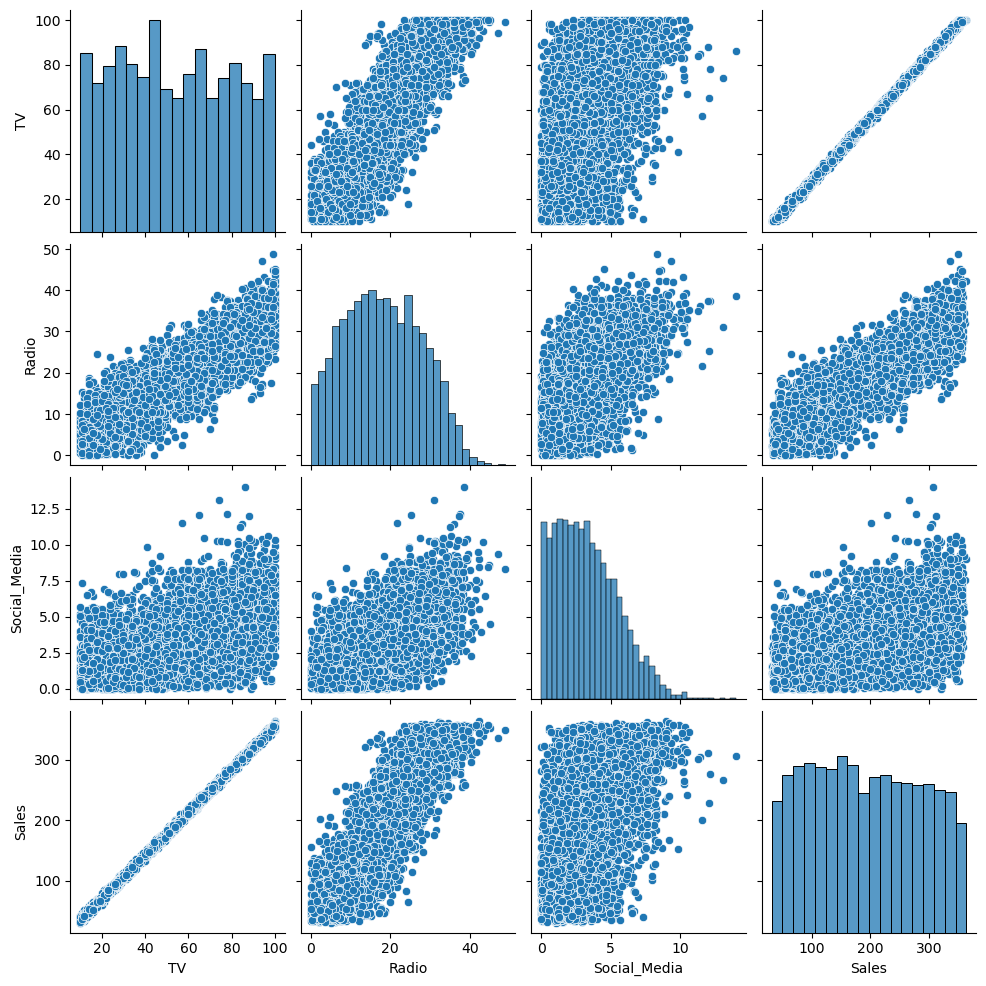

In [9]:
# Pairplot diagram
sns.pairplot(df)
plt.show()

From the scatter plot matrix, it can be observed that there is a linear relationship between;

- TV and Sales
- Radio and Sales
- Radio and TV

However, TV and Sales had a more perfectly linear relationship

In [10]:
# Correlation between variables
corr = df.corr()
corr

,TV,Radio,Social_Media,Sales
TV,1.000000,0.869158,0.527687,0.999497
Radio,0.869158,1.000000,0.606338,0.868638
Social_Media,0.527687,0.606338,1.000000,0.527446
Sales,0.999497,0.868638,0.527446,1.000000


TV had the highest correlation with sales in comparison to other independent variables (Radio and Social Meadia).
Hence, TV is a better predictor for sales, and should be used to build the Simple regression model

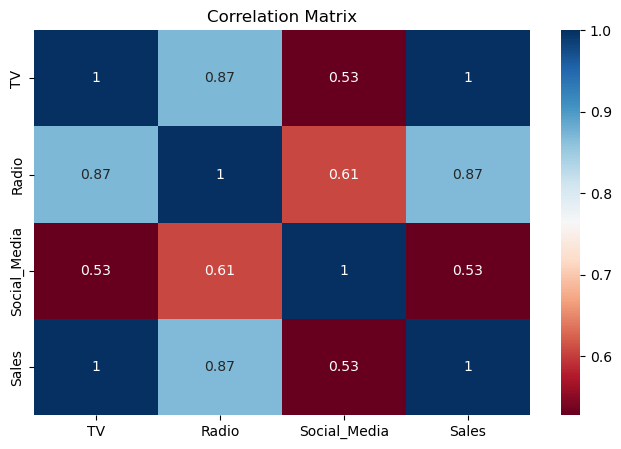

In [11]:
# Visualization of correlations
plt.figure(figsize=(8,5))
sns.heatmap(corr, cmap='RdBu', annot=True)

plt.title("Correlation Matrix")
plt.show()

## **Building the Simple Linear Regression Model**

In [12]:
# Model Data
ols_data = df[["Sales", "TV", ]]

In [13]:
# Formula
# y = bx + c + e
ols_formula = "Sales ~ TV"

In [14]:
# Fitting the model
OLS = ols(ols_formula, ols_data)
model = OLS.fit()

### **Results**

In [15]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:53:53   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1325      0.101     -1.317      0.188      -0.330       0.065
TV             3.5615      0.002   2125.272      0.000       3.558       3.565
==============================================================================
Omnibus:                        0.052   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.974   Jarque-Bera (JB):                0.031
Skew:                          -0.001   Prob(JB):                        0.985
Kurtosis:                       3.012   Cond. No.                         138.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## **Checking Assumptions**

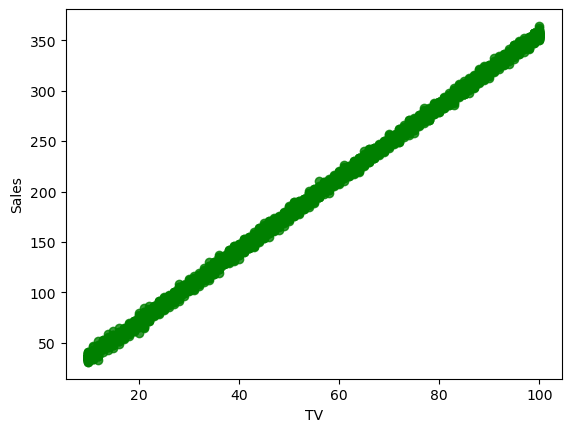

In [16]:
# Linearity check
sns.regplot(x = "TV", y = "Sales", data = ols_data, color='green')
plt.show()

In [17]:
# Predictor variable
X = ols_data["TV"]

X.head()

0    16.0
1    13.0
2    41.0
3    83.0
4    15.0
Name: TV, dtype: float64

In [18]:
# Get predictions from model
fitted_values = model.predict(X)
fitted_values.head()

0     56.851733
1     46.167191
2    145.889585
3    295.473177
4     53.290219
dtype: float64

In [19]:
# Calculate residuals
residuals = model.resid

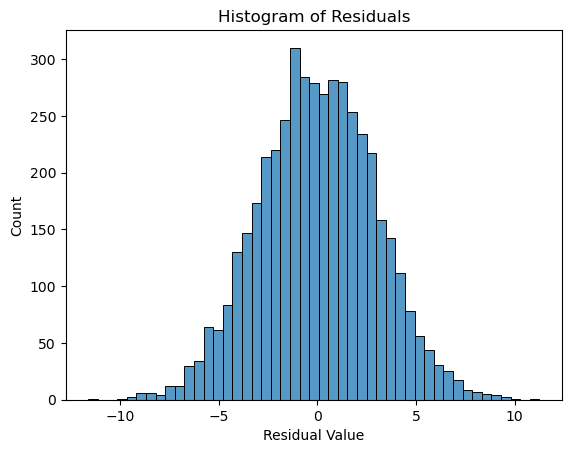

In [20]:
# Checking Normality Assumption
fig = sns.histplot(residuals)
fig.set_xlabel("Residual Value")
fig.set_title("Histogram of Residuals")
plt.show()

From the histogram above, it can be deduced that the normality assumption was met since the Residual values are almost evenly distributed

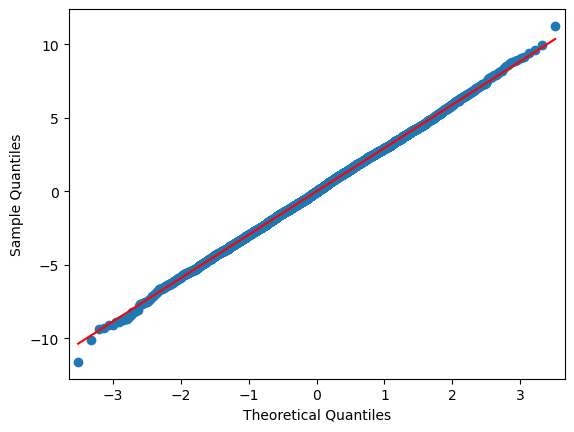

In [21]:
fig = sm.qqplot(model.resid, line = 's')
plt.show()

The QQ Plot above validates the findings from the histogram that the normality assumption was indeed met

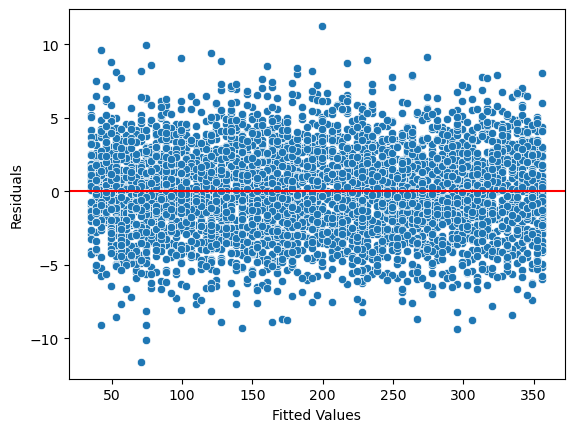

In [22]:
# Homoscedasticity assumption check
fig = sns.scatterplot(x=fitted_values, y=residuals)

fig.axhline(y=0,color='red')

fig.set_xlabel("Fitted Values")
fig.set_ylabel("Residuals")

plt.show()

### **Key Model Results & Interpretations**


- R-squared = 0.999

- TV coefficient = 3.5615

- TV p-value = 0.000

- Intercept p-value = 0.188

- The high R-squared result indicates that TV advertising investment has a very strong relationship with sales performance in this dataset and that changes in TV advertising expenditure are highly predictive of changes in sales.

- The TV coefficient value shows that for every one-unit increase in TV advertising spending, sales are expected to increase by approximately 3.56 units. This suggests that increasing investment in TV advertising is associated with a substantial increase in expected sales.

- The relationship between TV advertising and sales is statistically significant (p < 0.001). herefore, TV advertising is a meaningful predictor of sales and the observed relationship is unlikely to have occurred by chance.

- The intercept had a p-value of 0.188, meaning that the baseline sales value when TV advertising is zero was not statistically significant. However, the main business focus is the TV advertising coefficient, which demonstrates a significant impact on sales.

### **Recommendation**

- Based on the regression analysis, TV advertising should receive the highest priority in future marketing budget allocation

- The organization should consider increasing or maintaining investment in TV advertising as the primary marketing channel to maximize sales returns.